# Коллаборативные модели

Коллаборативные модели специализируются на задачах рекомендаций. Их главная проблема - холодный старт
Содержание:
1. Подготовка данных
2. Baseline
3. KNNWithMeans
4. KNNBaseline
5. SVD
6. SVD++
7. NMF
8. Сравнение моделей и анализ лучшей
9. Артефакты
10. Заключение

## 1. Подготовка данных

### 1.1. Импорты

In [39]:
import numpy as np
import pandas as pd
import os

random_state = 42
models_results = []
models_preds = {}

### 1.2. Загрузка данных

In [40]:
data_path = os.path.join('..', 'data', 'ml-latest-small')

# Загружаем подготовленные датасеты
train = pd.read_csv(os.path.join(data_path, 'train.csv'))
val = pd.read_csv(os.path.join(data_path, 'val.csv'))
test = pd.read_csv(os.path.join(data_path, 'test.csv'))

print(f'train {train.shape}')
print(f'val {val.shape}')
print(f'test {test.shape}')

train (70584, 44)
val (10084, 44)
test (20168, 44)


### 1.3. Отделяем target

In [41]:
features = [col for col in train.columns if col not in ['rating', 'movieId', 'userId']]

X_train = train[features]
X_val = val[features]
X_test = test[features]

y_train = train['rating'].values
y_val = val['rating'].values
y_test = test['rating'].values

### 1.4. Предобработка данных

In [42]:
X_train_no_features = train[['userId', 'movieId']]
X_val_no_features = val[['userId', 'movieId']]
X_test_no_features = test[['userId', 'movieId']]

print(f'train {X_train_no_features.shape}')
print(f'val {X_val_no_features.shape}')
print(f'test {X_test_no_features.shape}')

train (70584, 2)
val (10084, 2)
test (20168, 2)


## 2. BiasBaseline

### 2.1. Импорты

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

### 2.2. Класс BiasBaseline

In [44]:
class BiasBaseline:
    """
    Коллаборативный базлайн:  r_hat = glob_avg + bias_user + bias_item
    """

    def __init__(self, reg=10.0, clip=(0.5, 5.0)):
        self.reg = reg #  регуляризация для ослабления влияния малого количества оценок
        self.clip = clip #  границы оценок

        # выучиваемые параметры
        self.glob_avg_ = None
        self.bias_user_ = None  #  на сколько в среднем пользователь более/менее щедр
        self.bias_item_ = None  #  на сколько в среднем фильм получает оценку больше/меньше

    def fit(self, X, y):
        df = pd.DataFrame({
            "userId": X["userId"].values,
            "movieId": X["movieId"].values,
            "rating": np.asarray(y, dtype=float),
        })

        # 1) общий уровень
        self.glob_avg_ = df["rating"].mean()

        # 2) смещение фильма: сначала фильмы. Стабильнее, тк оценок на фильм больше, чем оценок от одного пользователя
        m = df.groupby("movieId")["rating"].agg(["sum", "count"])
        self.bias_item_ = (m["sum"] - self.glob_avg_ * m["count"]) / (self.reg + m["count"]) #  смещение с регуляризацией
        df["bias_item"] = df["movieId"].map(self.bias_item_)

        # 3) смещение юзера — на остатке после вычета glob_avg_ и bias_item_
        df["resid"] = df["rating"] - self.glob_avg_ - df["bias_item"] #  смещение по каждму фильму, который оценил пользователь
        user = df.groupby("userId")["resid"].agg(["sum", "count"])
        self.bias_user_ = user["sum"] / (self.reg + user["count"]) #  считаем среднее смещение с регуляризацией

        return self #  позволяет писать model.fit(...).predict(...)

    def predict(self, X):
        # незнакомый id -> смещение 0
        bias_user = X["userId"].map(self.bias_user_).fillna(0.0).to_numpy()
        bias_item = X["movieId"].map(self.bias_item_).fillna(0.0).to_numpy()

        preds = self.glob_avg_ + bias_user + bias_item

        if self.clip is not None:
            preds = np.clip(preds, self.clip[0], self.clip[1])

        return preds

### 2.3. Вспомогательные функции

In [45]:
def grid_search_custom(model_constructor, param_grid, X_train, y_train, X_val, y_val):
    """
    Рекурсивный перебор гиперпараметров
    Параметры:
        model_constructor - функция, создающая модель (например, lambda: DecisionTreeRegressor(random_state=42))
        param_grid - словарь с параметрами и списками значений
        X_train, y_train - обучающие данные
        X_val, y_val - валидационные данные
    Возвращает:
        best_params - словарь с лучшими параметрами
        best_score - лучшая метрика (RMSE)
        best_model - лучшая обученная модель
    """
    best_params = {}
    best_score = float('inf')
    best_model = None

    def _recursive_search(current_params, remaining_params):
        nonlocal best_params, best_score, best_model

        if not remaining_params:
            # Все параметры зафиксированы — обучаем модель
            model = model_constructor(**current_params)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))

            if rmse < best_score:
                best_score = rmse
                best_params = current_params.copy()
                best_model = model

                print(f"{current_params} -> RMSE: {rmse:.4f}")

            return

        # Берем следующий параметр для перебора
        param_name, param_values = list(remaining_params.items())[0]
        remaining = {k: v for k, v in remaining_params.items() if k != param_name}

        for value in param_values:
            current_params[param_name] = value
            _recursive_search(current_params, remaining)

    _recursive_search({}, param_grid)

    print("End...")
    
    return best_params, best_score, best_model

def evaluate(y_true: pd.Series, y_pred: pd.Series, name: str) -> tuple[float, float]:
    """
    Функция оценки. Считает и выводит rmse и mae.
    Параметры:
      y_true - серия с реальными оценками
      y_pred - серия с предсказанными оценками
      name - название датасета
    Возвращает:
      rmse - средне квадратическое отклонение
      mae - среднее абсолютное отклонение
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name}: RMSE = {rmse:.4f}, MAE = {mae:.4f}")

    return rmse, mae

### 2.4. Обучение 

In [46]:
model_constructor = lambda **kwargs: BiasBaseline(**kwargs)
param_grid = {'reg': [1.0, 5.0, 10.0, 25.0, 50.0]}

best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid, 
    X_train_no_features, 
    y_train, 
    X_val_no_features, 
    y_val
)

{'reg': 1.0} -> RMSE: 0.9873
{'reg': 5.0} -> RMSE: 0.9798
End...


### 2.5. Оценка

In [47]:
print(best_params)

y_train_pred = best_model.predict(X_train_no_features)
y_test_pred = best_model.predict(X_test_no_features)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

results = {
    'name': 'BiasBaseline',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)
models_preds['BiasBaseline'] = y_test_pred

{'reg': 5.0}
Train: RMSE = 0.8245, MAE = 0.6379
Test: RMSE = 1.0253, MAE = 0.7985


## 3. KNNWithMeans

### 3.1. Импорты

In [48]:
from surprise import Dataset, Reader, KNNWithMeans

### 3.2. Вспомогательные инструменты

In [49]:
class SurpriseWrapper:
    """Делает из любой модели surprise sklearn-подобную: fit(X, y) / predict(X)."""

    def __init__(self, algo_class, **params):
        self.algo_class = algo_class
        self.params = params

    def fit(self, X, y):
        df = pd.DataFrame({
            "userId": X["userId"].values,
            "movieId": X["movieId"].values,
            "rating": np.asarray(y, dtype=float),
        })
        reader = Reader(rating_scale=(0.5, 5.0))
        trainset = Dataset.load_from_df(
            df[["userId", "movieId", "rating"]], reader
        ).build_full_trainset()

        params = {"verbose": False, **self.params}
        self.model_ = self.algo_class(**params)
        self.model_.fit(trainset)
        return self

    def predict(self, X):
        preds = [
            self.model_.predict(u, i).est
            for u, i in zip(X["userId"].values, X["movieId"].values)
        ]
        return np.clip(np.asarray(preds), 0.5, 5.0)

### 3.3. User-based

#### 3.3.1. Обучение

In [50]:
model_constructor = lambda **kw: SurpriseWrapper(KNNWithMeans, **kw)
param_grid = {
    "k": [20, 40, 80],
    "min_k": [1, 3],
    "sim_options": [
        {"name": "msd", "user_based": True},
        {"name": "cosine", "user_based": True},
        {"name": "pearson", "user_based": True},
        {"name": "pearson_baseline", "user_based": True, "shrinkage": 100},
    ]
}

best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid, 
    X_train_no_features, 
    y_train, 
    X_val_no_features, 
    y_val
)

{'k': 20, 'min_k': 1, 'sim_options': {'name': 'msd', 'user_based': True}} -> RMSE: 1.0435
{'k': 20, 'min_k': 1, 'sim_options': {'name': 'pearson', 'user_based': True}} -> RMSE: 1.0434
{'k': 20, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': True}} -> RMSE: 1.0403
{'k': 20, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': True}} -> RMSE: 1.0372
{'k': 40, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': True}} -> RMSE: 1.0370
{'k': 80, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': True}} -> RMSE: 1.0369
End...


#### 3.3.2. Оценка

In [51]:
print(best_params)

y_train_pred = best_model.predict(X_train_no_features)
y_test_pred = best_model.predict(X_test_no_features)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

results = {
    'name': 'UserBased_KNNWithMeans',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)
models_preds['UserBased_KNNWithMeans'] = y_test_pred

{'k': 80, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': True}}
Train: RMSE = 0.6755, MAE = 0.5087
Test: RMSE = 1.0785, MAE = 0.8540


### 3.4. Item-based

#### 3.4.1. Обучение

In [52]:
model_constructor = lambda **kw: SurpriseWrapper(KNNWithMeans, **kw)
param_grid = {
    "k": [20, 40, 80],
    "min_k": [1, 3],
    "sim_options": [
        {"name": "msd", "user_based": False},
        {"name": "cosine", "user_based": False},
        {"name": "pearson", "user_based": False},
        {"name": "pearson_baseline", "user_based": False, "shrinkage": 100},
    ]
}

best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid, 
    X_train_no_features, 
    y_train, 
    X_val_no_features, 
    y_val
)

{'k': 20, 'min_k': 1, 'sim_options': {'name': 'msd', 'user_based': False}} -> RMSE: 1.0407
{'k': 20, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': False}} -> RMSE: 1.0406
{'k': 40, 'min_k': 1, 'sim_options': {'name': 'msd', 'user_based': False}} -> RMSE: 1.0403
{'k': 40, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': False}} -> RMSE: 1.0401
{'k': 80, 'min_k': 1, 'sim_options': {'name': 'msd', 'user_based': False}} -> RMSE: 1.0398
{'k': 80, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': False}} -> RMSE: 1.0397
End...


#### 3.4.2. Оценка

In [53]:
print(best_params)

y_train_pred = best_model.predict(X_train_no_features)
y_test_pred = best_model.predict(X_test_no_features)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

results = {
    'name': 'ItemBased_KNNWithMeans',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)
models_preds['ItemBased_KNNWithMeans'] = y_test_pred

{'k': 80, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': False}}
Train: RMSE = 0.6025, MAE = 0.4588
Test: RMSE = 1.0790, MAE = 0.8544


## 4. KNNBaseline

### 4.1. Импорты

In [54]:
from surprise import KNNBaseline

### 4.2. User-based

#### 4.2.1. Обучение

In [55]:
model_constructor = lambda **kw: SurpriseWrapper(KNNBaseline, **kw)
param_grid = {
    "k": [20, 40, 80],
    "min_k": [1, 3],
    "sim_options": [
        {"name": "msd", "user_based": True},
        {"name": "cosine", "user_based": True},
        {"name": "pearson", "user_based": True},
        {"name": "pearson_baseline", "user_based": True, "shrinkage": 100},
    ]
}

best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid, 
    X_train_no_features, 
    y_train, 
    X_val_no_features, 
    y_val
)

{'k': 20, 'min_k': 1, 'sim_options': {'name': 'msd', 'user_based': True}} -> RMSE: 0.9953
{'k': 20, 'min_k': 1, 'sim_options': {'name': 'pearson', 'user_based': True}} -> RMSE: 0.9950
{'k': 20, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': True}} -> RMSE: 0.9920
{'k': 20, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': True}} -> RMSE: 0.9893
{'k': 40, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': True}} -> RMSE: 0.9890
{'k': 80, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': True}} -> RMSE: 0.9890
End...


#### 4.2.2. Оценка

In [56]:
print(best_params)

y_train_pred = best_model.predict(X_train_no_features)
y_test_pred = best_model.predict(X_test_no_features)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

results = {
    'name': 'UserBased_KNNBaseline',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)
models_preds['UserBased_KNNBaseline'] = y_test_pred

{'k': 80, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': True}}
Train: RMSE = 0.6561, MAE = 0.4978
Test: RMSE = 1.0338, MAE = 0.8029


### 4.3. Item-based

#### 4.3.1. Обучение

In [57]:
model_constructor = lambda **kw: SurpriseWrapper(KNNBaseline, **kw)
param_grid = {
    "k": [20, 40, 80],
    "min_k": [1, 3],
    "sim_options": [
        {"name": "msd", "user_based": False},
        {"name": "cosine", "user_based": False},
        {"name": "pearson", "user_based": False},
        {"name": "pearson_baseline", "user_based": False, "shrinkage": 100},
    ]
}

best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid, 
    X_train_no_features, 
    y_train, 
    X_val_no_features, 
    y_val
)

{'k': 20, 'min_k': 1, 'sim_options': {'name': 'msd', 'user_based': False}} -> RMSE: 0.9890
{'k': 20, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': False}} -> RMSE: 0.9888
{'k': 20, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': False}} -> RMSE: 0.9885
{'k': 20, 'min_k': 3, 'sim_options': {'name': 'pearson_baseline', 'user_based': False, 'shrinkage': 100}} -> RMSE: 0.9878
{'k': 40, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': False}} -> RMSE: 0.9876
{'k': 40, 'min_k': 3, 'sim_options': {'name': 'pearson_baseline', 'user_based': False, 'shrinkage': 100}} -> RMSE: 0.9876
{'k': 80, 'min_k': 1, 'sim_options': {'name': 'msd', 'user_based': False}} -> RMSE: 0.9874
{'k': 80, 'min_k': 3, 'sim_options': {'name': 'msd', 'user_based': False}} -> RMSE: 0.9872
{'k': 80, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': False}} -> RMSE: 0.9871
End...


#### 4.3.2. Оценка

In [58]:
print(best_params)

y_train_pred = best_model.predict(X_train_no_features)
y_test_pred = best_model.predict(X_test_no_features)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

results = {
    'name': 'ItemBased_KNNBaseline',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)
models_preds['ItemBased_KNNBaseline'] = y_test_pred

{'k': 80, 'min_k': 3, 'sim_options': {'name': 'pearson', 'user_based': False}}
Train: RMSE = 0.5800, MAE = 0.4463
Test: RMSE = 1.0338, MAE = 0.8028


## 5. SVD

Комбинация baseline и эмбендинга

### 5.1. Импорты

In [59]:
from surprise import SVD

### 5.2. Обучение

In [60]:
model_constructor = lambda **kw: SurpriseWrapper(SVD, **kw)
param_grid = {
    "n_factors": [20, 50, 100],
    "n_epochs": [20, 50],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.05, 0.1],
    "random_state": [random_state]
}

best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid, 
    X_train_no_features, 
    y_train, 
    X_val_no_features, 
    y_val
)

{'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.002, 'reg_all': 0.02, 'random_state': 42} -> RMSE: 0.9859
{'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.002, 'reg_all': 0.05, 'random_state': 42} -> RMSE: 0.9853
{'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.002, 'reg_all': 0.1, 'random_state': 42} -> RMSE: 0.9845
{'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1, 'random_state': 42} -> RMSE: 0.9821
{'n_factors': 20, 'n_epochs': 50, 'lr_all': 0.005, 'reg_all': 0.1, 'random_state': 42} -> RMSE: 0.9811
{'n_factors': 100, 'n_epochs': 50, 'lr_all': 0.005, 'reg_all': 0.1, 'random_state': 42} -> RMSE: 0.9810
End...


### 5.3. Оценка

In [61]:
print(best_params)

y_train_pred = best_model.predict(X_train_no_features)
y_test_pred = best_model.predict(X_test_no_features)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

results = {
    'name': 'SVD',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)
models_preds['SVD'] = y_test_pred

{'n_factors': 100, 'n_epochs': 50, 'lr_all': 0.005, 'reg_all': 0.1, 'random_state': 42}
Train: RMSE = 0.6920, MAE = 0.5415
Test: RMSE = 1.0264, MAE = 0.7970


## 6. SVD++

Модель является модификаецией SVD: учитывает факт взаимодействия пользователя с другими фильмами

### 6.1. Импорты

In [62]:
from surprise import SVDpp

### 6.2. Обучение

In [63]:
model_constructor = lambda **kw: SurpriseWrapper(SVDpp, **kw)

param_grid = {
    "n_factors": [20, 50],
    "n_epochs": [20],
    "lr_all": [0.002, 0.005],
    "reg_all": [0.02, 0.1],
    "random_state": [random_state],
    "cache_ratings": [True]
}

best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid,
    X_train_no_features,
    y_train,
    X_val_no_features,
    y_val
)

{'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.002, 'reg_all': 0.02, 'random_state': 42, 'cache_ratings': True} -> RMSE: 0.9850
{'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.002, 'reg_all': 0.1, 'random_state': 42, 'cache_ratings': True} -> RMSE: 0.9845
{'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.02, 'random_state': 42, 'cache_ratings': True} -> RMSE: 0.9824
{'n_factors': 20, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1, 'random_state': 42, 'cache_ratings': True} -> RMSE: 0.9819
{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1, 'random_state': 42, 'cache_ratings': True} -> RMSE: 0.9816
End...


### 6.3. Оценка

In [64]:
print(best_params)

y_train_pred = best_model.predict(X_train_no_features)
y_test_pred = best_model.predict(X_test_no_features)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

results = {
    'name': 'SVDpp',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)
models_preds['SVDpp'] = y_test_pred

{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.1, 'random_state': 42, 'cache_ratings': True}
Train: RMSE = 0.8092, MAE = 0.6291
Test: RMSE = 1.0294, MAE = 0.7998


## 7. NMF

Модель работает по алгоритму SVD, однако все скрытые признаки неотрицательные

### 7.1. Иипорты

In [65]:
from surprise import NMF

### 7.2. Обучение

In [66]:
model_constructor = lambda **kw: SurpriseWrapper(NMF, **kw)

param_grid = {
    "n_factors": [15, 30, 50],
    "n_epochs": [50],
    "reg_pu": [0.05, 0.1],
    "reg_qi": [0.05, 0.1],
    "random_state": [random_state],
    "biased": [True]
}

best_params, best_score, best_model = grid_search_custom(
    model_constructor,
    param_grid,
    X_train_no_features,
    y_train,
    X_val_no_features,
    y_val,
)

{'n_factors': 15, 'n_epochs': 50, 'reg_pu': 0.05, 'reg_qi': 0.05, 'random_state': 42, 'biased': True} -> RMSE: 1.1003
{'n_factors': 15, 'n_epochs': 50, 'reg_pu': 0.05, 'reg_qi': 0.1, 'random_state': 42, 'biased': True} -> RMSE: 0.9878
End...


### 7.3. Оценка

In [67]:
print(best_params)

y_train_pred = best_model.predict(X_train_no_features)
y_test_pred = best_model.predict(X_test_no_features)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

results = {
    'name': 'NMF',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae
}
for param, value in best_params.items():
    results[param] = [value]

models_results.append(results)
models_preds['NMF'] = y_test_pred

{'n_factors': 15, 'n_epochs': 50, 'reg_pu': 0.05, 'reg_qi': 0.1, 'random_state': 42, 'biased': True}
Train: RMSE = 0.7191, MAE = 0.5487
Test: RMSE = 1.0358, MAE = 0.8135


## 8. Сравнение моделей и анализ лучшей

### 8.1. Импорты

In [68]:
import matplotlib.pyplot as plt

### 8.2. Сравнение моделей

In [69]:
results_df = pd.DataFrame(models_results)
results_df

,name,train_rmse,train_mae,test_rmse,test_mae,reg,k,min_k,sim_options,n_factors,n_epochs,lr_all,reg_all,random_state,cache_ratings,reg_pu,reg_qi,biased
0,BiasBaseline,0.824466,0.637939,1.025338,0.798456,[5.0],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,UserBased_KNNWithMeans,0.675464,0.508735,1.078468,0.854010,NaN,[80],[3],"[{'name': 'pearson', 'user_based': True}]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ItemBased_KNNWithMeans,0.602489,0.458796,1.078972,0.854358,NaN,[80],[3],"[{'name': 'msd', 'user_based': False}]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,UserBased_KNNBaseline,0.656062,0.497766,1.033782,0.802892,NaN,[80],[3],"[{'name': 'pearson', 'user_based': True}]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ItemBased_KNNBaseline,0.579984,0.446279,1.033790,0.802798,NaN,[80],[3],"[{'name': 'pearson', 'user_based': False}]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,SVD,0.692029,0.541469,1.026400,0.797007,NaN,NaN,NaN,NaN,[100],[50],[0.005],[0.1],[42],NaN,NaN,NaN,NaN
6,SVDpp,0.809160,0.629080,1.029354,0.799815,NaN,NaN,NaN,NaN,[50],[20],[0.005],[0.1],[42],[True],NaN,NaN,NaN
7,NMF,0.719101,0.548743,1.035802,0.813517,NaN,NaN,NaN,NaN,[15],[50],NaN,NaN,[42],NaN,[0.05],[0.1],[True]


### 8.3. Анализ лучшей модели

In [70]:
best_row = results_df.loc[results_df['test_rmse'].idxmin()]

best_params = best_row.to_dict()

for name, value in best_params.items():
    if isinstance(value, list):
        best_params[name] = value[0]
    else: 
        best_params[name] = value

best_params

{'name': 'BiasBaseline',
 'train_rmse': 0.8244662286448134,
 'train_mae': 0.637939019627765,
 'test_rmse': 1.0253377698839907,
 'test_mae': 0.7984559176895126,
 'reg': 5.0,
 'k': nan,
 'min_k': nan,
 'sim_options': nan,
 'n_factors': nan,
 'n_epochs': nan,
 'lr_all': nan,
 'reg_all': nan,
 'random_state': nan,
 'cache_ratings': nan,
 'reg_pu': nan,
 'reg_qi': nan,
 'biased': nan}

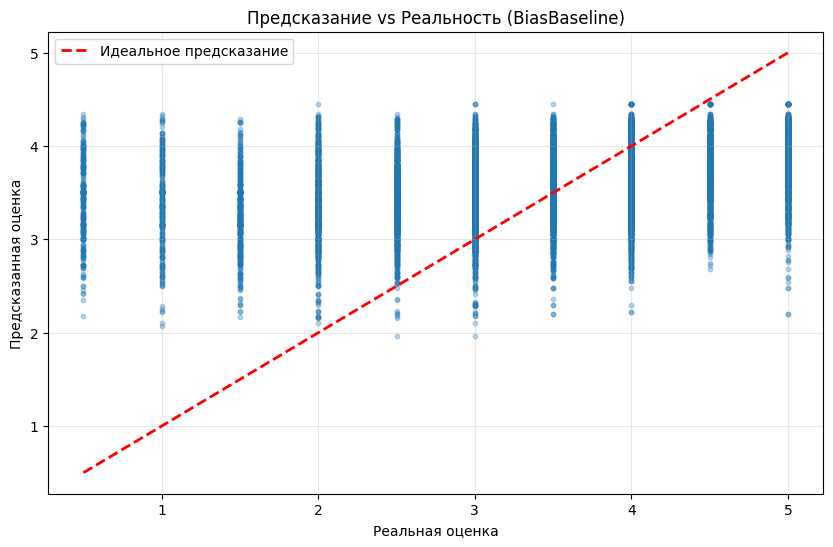

In [71]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test, models_preds[best_params['name']], alpha=0.3, s=10)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
ax.set_xlabel('Реальная оценка')
ax.set_ylabel('Предсказанная оценка')
ax.set_title(f"Предсказание vs Реальность ({best_params['name']})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 9. Артефакты

In [ ]:
import json

artifacts_path = os.path.join('..', 'artifacts', 'experiments', 'exp05')
os.makedirs(artifacts_path, exist_ok=True)

results_df.to_csv(os.path.join(artifacts_path, 'runs.csv'), index=False)

with open(os.path.join(artifacts_path, 'best_model_params.json'), 'w') as f:
    json.dump(best_params, f, indent=4)

fig.savefig(os.path.join(artifacts_path, 'prediction_vs_actual.png'), dpi=150, bbox_inches='tight')

## 10. Заключение

По итогу эксперимента коллаборативные модели показали результаты на уровне предыдущих экспериментов. Это хороший показатель, так как холодный старт очень сложен для подобных моделей